# Detection pipeline

**For real data:** edit `~/.piepy/config.json` so `paths.presentation` / `paths.analysis` point at your dirs. (Real sessions need their full artifacts — e.g. opto-pattern images for opto sessions — or parsing will raise.)

In [1]:
import os, glob
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from piepy.core.config import config
from piepy.core.registry import get_session_class
from piepy.core.hub import Hub
from piepy.simulations.session import simulate_session
from piepy.stats import aggregate, Rate, Median
from piepy.fitting import fit

pres = config.paths["presentation"][0]
print('presentation dir:', pres)

presentation dir: /Users/kaan/data/presentation


In [2]:
sessions = ['221108_KC142_detect_opto120_HVA__no_cam_KC',
            '230228_KC143_detect_opto120_HVA__no_cam_KC',
            '230228_KC144_detect_opto120_HVA__no_cam_KC',
            '240514_KC149_detect_opto120_HVA__no_cam_KC',
            '240625_KC147_detect_opto120_HVA__no_cam_KC',
            '240627_KC148_detect_opto120_HVA__1P_KC',
            '240817_KC151_detect_opto120_HVA__no_cam_KC',
            '240828_KC152_detect_opto120_HVA__no_cam_KC']

## Parse a single session
Builds the Session, parses each run, and stacks them onto one session clock. Wrapped defensively so a real-data hiccup prints a clear error instead of aborting.

In [3]:
exp_name = "240627_KC148_detect_opto120_HVA__1P_KC"
sess = get_session_class("detection")(exp_name, load_flag=False)
df = sess.concatenate_runs("detection")
print(exp_name, "->", df.shape)



[26-06-19 16:18:22] - Parsing stimlog...


Reading logs: 100%|██████████| 2/2 [00:00<00:00, 116.16it/s]

[26-06-19 16:18:22] - Parsing riglog...



Reading logs: 100%|██████████| 13/13 [00:00<00:00, 1229.22it/s]

[26-06-19 16:18:22] - No data found for log key(s) : ['imaging', 'button', 'lap', 'act0', 'act1']
[26-06-19 16:18:22] - The number of screen pulses 877 does not match the visual stimulation photo:878 log.
[26-06-19 16:18:22] - Read rawdata
[26-06-19 16:18:22] - Adding total iStim column


[26-06-19 16:18:22] - Found saved data: /Users/kaan/data/analysis/240627_KC148_detect_opto120_HVA__1P_KC/runData.parquet


Extracting trial data:: 100%|██████████| 604/604 [00:13<00:00, 44.80it/s]


[26-06-19 16:18:35] - Saved session data to /Users/kaan/data/analysis/240627_KC148_detect_opto120_HVA__1P_KC
[26-06-19 16:18:35] - Done! t=13.88 s
240627_KC148_detect_opto120_HVA__1P_KC -> (604, 65)


## Cohort across many sessions (`Hub`)
`Hub` runs each session in parallel and stacks them into one cohort table. It already isolates per-session failures (a bad session warns and is skipped).

In [7]:
cohort = None
if sessions:
    try:
        hub = Hub("detection")
        hub.initialize([os.path.basename(s) for s in sessions], load_sessions=False)
        cohort = hub.data
        print('cohort:', None if cohort is None else cohort.shape)
    except Exception as e:
        print("Hub gather failed:", type(e).__name__, e)

[26-06-19 16:20:19] - Hub set to paradigm 'detection'
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing stimlog...
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - No data found for log key(s) : ['imaging', 'button', 'lap', 'facecam', 'eyecam', 'act0', 'act1']
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - The number of screen pulses 675 does not match the visual stimulation photo:676 log.
[26-06-19 16:20:21] - Read rawdata
[26-06-19 16:20:21] - No data found for log key(s) : ['imaging', 'button', 'lap', 'facecam', 'eyecam', 'act0', 'act1'

Extracting trial data::   0%|          | 0/621 [00:00<?, ?it/s]

[26-06-19 16:20:21] - No data found for log key(s) : ['imaging', 'button', 'lap', 'facecam', 'eyecam', 'act0', 'act1']
[26-06-19 16:20:21] - The number of screen pulses 663 does not match the visual stimulation photo:664 log.
[26-06-19 16:20:21] - The number of screen pulses 1109 does not match the visual stimulation photo:1110 log.
[26-06-19 16:20:21] - Read rawdata
[26-06-19 16:20:21] - Read rawdata
[26-06-19 16:20:21] - Parsing riglog...
[26-06-19 16:20:21] - No data found for log key(s) : ['imaging', 'button', 'lap', 'facecam', 'eyecam', 'act0', 'act1']
[26-06-19 16:20:21] - The number of screen pulses 939 does not match the visual stimulation photo:940 log.
[26-06-19 16:20:21] - Read rawdata
[26-06-19 16:20:21] - Adding total iStim column
[26-06-19 16:20:21] - The number of screen pulses 977 does not match the visual stimulation photo:978 log.
[26-06-19 16:20:21] - Read rawdata
[26-06-19 16:20:21] - The number of screen pulses 763 does not match the visual stimulation photo:764 lo

Extracting trial data::   1%|          | 5/586 [00:00<00:24, 24.02it/s]

[26-06-19 16:20:21] - Adding total iStim column
[26-06-19 16:20:21] - Adding total iStim column
[26-06-19 16:20:21] - Found saved data: /Users/kaan/data/analysis/230228_KC143_detect_opto120_HVA__no_cam_KC/runData.parquet
[26-06-19 16:20:21] - Found saved data: /Users/kaan/data/analysis/240627_KC148_detect_opto120_HVA__1P_KC/runData.parquet


...

[26-06-19 16:20:41] - Saved session data to /Users/kaan/data/analysis/240627_KC148_detect_opto120_HVA__1P_KC
[26-06-19 16:20:41] - Done! t=20.95 s


Extracting trial data::  99%|█████████▉| 733/737 [00:24<00:00, 48.93it/s]

[26-06-19 16:20:45] - No rig response time to interpolate; copying state response time.
[26-06-19 16:20:45] - Saved session data to /Users/kaan/data/analysis/230228_KC144_detect_opto120_HVA__no_cam_KC
[26-06-19 16:20:45] - Done! t=25.00 s


Extracting trial data:: 100%|██████████| 737/737 [00:26<00:00, 28.07it/s]


[26-06-19 16:20:47] - No rig response time to interpolate; copying state response time.
[26-06-19 16:20:47] - Saved session data to /Users/kaan/data/analysis/230228_KC143_detect_opto120_HVA__no_cam_KC
[26-06-19 16:20:47] - Done! t=26.93 s
cohort: (4717, 108)


## Psychometric: P(hit) vs signed contrast
Aggregate to a tidy per-condition estimate (Wilson CI), then fit a logistic.

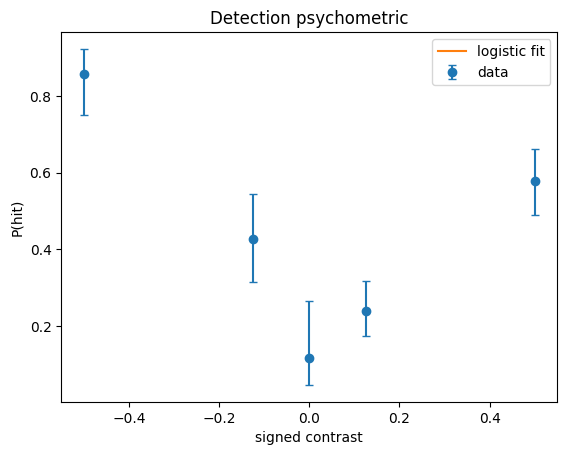

In [8]:
data = df if df is not None else simulate_session(
    paradigm="detection", n_trials=900, early_rate=0.1, seed=0)

# P(hit) vs signed contrast, excluding early (no-stimulus) trials
psy = aggregate(
    data.filter(pl.col("outcome") != "early"),
    group=["signed_contrast"],
    metrics=[Rate("outcome", success="hit")],
)
x, y = psy["signed_contrast"].to_numpy(), psy["value"].to_numpy()
n = psy["n"].to_numpy()
res = fit("logistic", x, y, n=n)

xx = np.linspace(x.min(), x.max(), 200)
plt.errorbar(x, y, yerr=[y - psy['ci_low'].to_numpy(), psy['ci_high'].to_numpy() - y],
             fmt="o", capsize=3, label="data")
plt.plot(xx, res.predict(xx), "-", label="logistic fit")
plt.xlabel("signed contrast"); plt.ylabel("P(hit)")
plt.title("Detection psychometric"); plt.legend(); plt.show()

## Reaction time vs signed contrast
Same `aggregate` API, a `Median` metric with its order-statistic CI.

In [9]:
rt = aggregate(data.filter(pl.col("outcome") == "hit"), group=["signed_contrast"], metrics=[Median("response_time")])
rt

signed_contrast,metric,value,ci_low,ci_high,n
f64,str,f64,f64,f64,i64
-0.5,"""median[response_time]""",247.0199,213.0199,314.0199,54
-0.125,"""median[response_time]""",498.0199,314.0199,697.0199,29
0.0,"""median[response_time]""",397.5199,147.0199,781.0199,4
0.125,"""median[response_time]""",364.0199,314.0199,480.0199,31
0.5,"""median[response_time]""",264.0199,231.0199,298.0199,70
